In [1]:
from w2v_engine import Word2VecEngine, Word2VecSGNS
import torch
import torch.nn.functional as F

import random
import numpy as np

import matplotlib.pyplot as plt

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Tânia\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [2]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    # Ensures deterministic behavior in some PyTorch operations
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

--- Loading and Cleaning: ./corpus_base/clean/corpus.txt ---
--- Generating Pairs ---
--- Trainning ---
Epoch 10, Loss: 0.002962, LR: 0.00195
Epoch 20, Loss: 0.002955, LR: 0.00181
Epoch 30, Loss: 0.002949, LR: 0.00159
Epoch 40, Loss: 0.002943, LR: 0.00131
Epoch 50, Loss: 0.002936, LR: 0.00100
Epoch 60, Loss: 0.002929, LR: 0.00069
Epoch 70, Loss: 0.002922, LR: 0.00041
Epoch 80, Loss: 0.002917, LR: 0.00019
Epoch 90, Loss: 0.002913, LR: 0.00005
Epoch 100, Loss: 0.002911, LR: 0.00000

Top 5 words similar with king:
kingdom: 0.6460
ordered: 0.6404
daughter: 0.6394
queen: 0.6009
begged: 0.5799

Top 5 words similar with cat:
mouse: 0.5943
tail: 0.5371
puss: 0.5330
miss: 0.5285
mistress: 0.5279

Top 5 results for king - man + woman:
happily: 0.6047
queen: 0.5678
princess: 0.5272
kingdom: 0.4990
promised: 0.4958

Top 5 results for father - man + woman:
child: 0.5859
mother: 0.5549
wept: 0.5325
husband: 0.5164
wishing: 0.5071

Top 5 results for brother - man + woman:
sister: 0.5883
brethren: 0.5

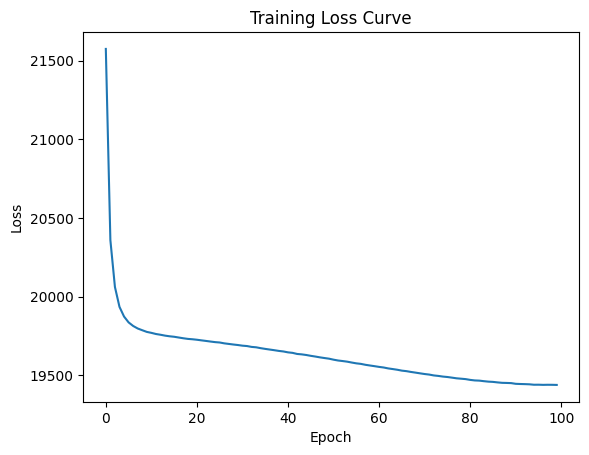

In [3]:
### BASE CORPUS
# 
# Configuration
EMB_DIM = 50
EPOCHS = 100
WINDOW = 20
MIN_COUNT = 5
CORPUS_TYPE = 'corpus_base'

engine_base = Word2VecEngine(embedding_dim=EMB_DIM)
corpus_base,counts_base = engine_base.prepare_data(CORPUS_TYPE, MIN_COUNT)
neg_table_base = engine_base.create_negative_table(counts_base)

model_base = Word2VecSGNS(len(engine_base.word2idx), EMB_DIM)

# --- START TRAINING ---
epoch_loss_base = engine_base.train(CORPUS_TYPE, model_base, corpus_base,neg_table_base, window_size=WINDOW, epochs=EPOCHS)


#plotting the loss curve
plt.plot(epoch_loss_base)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Curve')


engine_base.find_similar_words(model_base,word="king",top_n=5)
engine_base.find_similar_words(model_base,word="cat",top_n=5)
engine_base.find_similar_embedding(model_base,positive = ['king','woman'], negative = ['man'], top_n=5)
engine_base.find_similar_embedding(model_base,positive = ['father','woman'], negative = ['man'], top_n=5)
engine_base.find_similar_embedding(model_base,positive = ['brother','woman'], negative = ['man'], top_n=5)
engine_base.find_similar_embedding(model_base,positive = ['cats','mouse'], negative = ['cat'], top_n=5)


--- Loading and Cleaning: ./corpus_ext/clean/corpus.txt ---
--- Generating Pairs ---
--- Trainning ---
Epoch 10, Loss: 0.003028, LR: 0.00195
Epoch 20, Loss: 0.003025, LR: 0.00181
Epoch 30, Loss: 0.003022, LR: 0.00159
Epoch 40, Loss: 0.003017, LR: 0.00131
Epoch 50, Loss: 0.003011, LR: 0.00100
Epoch 60, Loss: 0.003005, LR: 0.00069
Epoch 70, Loss: 0.002999, LR: 0.00041
Epoch 80, Loss: 0.002994, LR: 0.00019
Epoch 90, Loss: 0.002990, LR: 0.00005
Epoch 100, Loss: 0.002989, LR: 0.00000

Top 5 words similar with king:
princess: 0.6780
kingdom: 0.6460
kings: 0.6225
queen: 0.5953
ordered: 0.5879

Top 5 words similar with cat:
puss: 0.6476
mouse: 0.5778
rat: 0.5730
ass: 0.5631
please: 0.5606

Top 5 results for king - man + woman:
princess: 0.6891
queen: 0.6668
fetch: 0.5846
hid: 0.5708
came: 0.5640

Top 5 results for father - man + woman:
mother: 0.6684
child: 0.6069
husband: 0.5628
wept: 0.5418
home: 0.5388

Top 5 results for brother - man + woman:
sister: 0.6071
mother: 0.5093
dismay: 0.4769
se

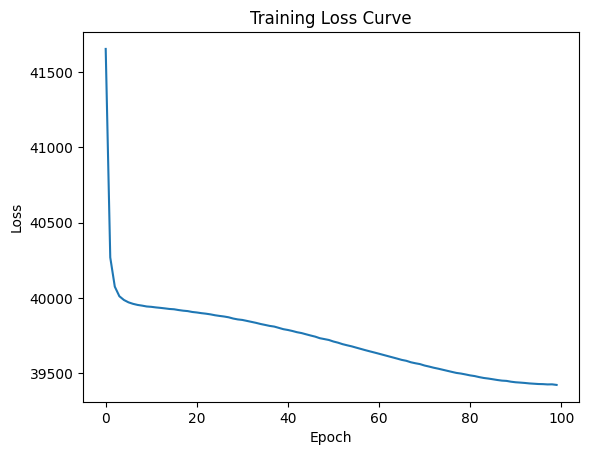

In [5]:
### EXTENDED CORPUS
# 
# Configuration
EMB_DIM = 50
EPOCHS = 100
WINDOW = 20
MIN_COUNT = 15
CORPUS_TYPE = 'corpus_ext'

engine_ext = Word2VecEngine(embedding_dim=EMB_DIM)
corpus_ext,counts_base = engine_ext.prepare_data(CORPUS_TYPE, MIN_COUNT)
neg_table_ext = engine_ext.create_negative_table(counts_base)

model_ext = Word2VecSGNS(len(engine_ext.word2idx), EMB_DIM)

# --- START TRAINING ---
epoch_loss_base = engine_ext.train(CORPUS_TYPE, model_ext, corpus_ext,neg_table_ext, window_size=WINDOW, epochs=EPOCHS)


#plotting the loss curve
plt.plot(epoch_loss_base)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Curve')


engine_ext.find_similar_words(model_ext,word="king",top_n=5)
engine_ext.find_similar_words(model_ext,word="cat",top_n=5)
engine_ext.find_similar_embedding(model_ext,positive = ['king','woman'], negative = ['man'], top_n=5)
engine_ext.find_similar_embedding(model_ext,positive = ['father','woman'], negative = ['man'], top_n=5)
engine_ext.find_similar_embedding(model_ext,positive = ['brother','woman'], negative = ['man'], top_n=5)
engine_ext.find_similar_embedding(model_ext,positive = ['cats','mouse'], negative = ['cat'], top_n=5)
